In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as f
import torch.optim as optim
import helper_utils
helper_utils.set_seed(42)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: CUDA


In [5]:
class SimpleCNN(nn.Module) :
    def __init__(self) :
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(p=0.4)

    def forward(self, x) :
        x = self.pool(f.relu(self.conv1(x)))
        x = self.pool(f.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = f.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_and_evaluate(learning_rate, device, n_epochs=32, batch_size=128, p_bar=None) :
    helper_utils.set_seed(42)
    model = SimpleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    train_loader, val_loader = helper_utils.get_dataset_dataloaders(batch_size = batch_size)
   
    history = helper_utils.train_model(
        model = model, 
        train_dataloader = train_loader,
        val_dataloader = val_loader, 
        optimizer = optimizer,
        loss_fcn = loss_fn,
        device = device,
        n_epochs = n_epochs,
        p_bar = p_bar
    )

    return history
    
    

In [6]:
learning_rates = [0.0002, 0.001, 0.003]

training_curves = []
n_epochs = 25
batch_size = 128

p_bar = helper_utils.get_p_bar(n_epochs)
num_learning_rates = len(learning_rates)

for i, lr in enumerate(learning_rates) :
    print(f"\nTraining with learning rate : {lr}\n")
    history = train_and_evaluate(learning_rate = lr, n_epochs = n_epochs, batch_size = batch_size, device = device, p_bar = p_bar)
    training_curves.append(history)
    if i < num_learning_rates - 1 :
        p_bar.reset()
    

Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/10 [00:00<?, ?it/s]


Training with learning rate : 0.0002



Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

At epoch 25: Training loss: 0.5971, Training accuracy: 0.7722
At epoch 25: Validation loss: 1.4837, Validation accuracy: 0.5900
Training complete



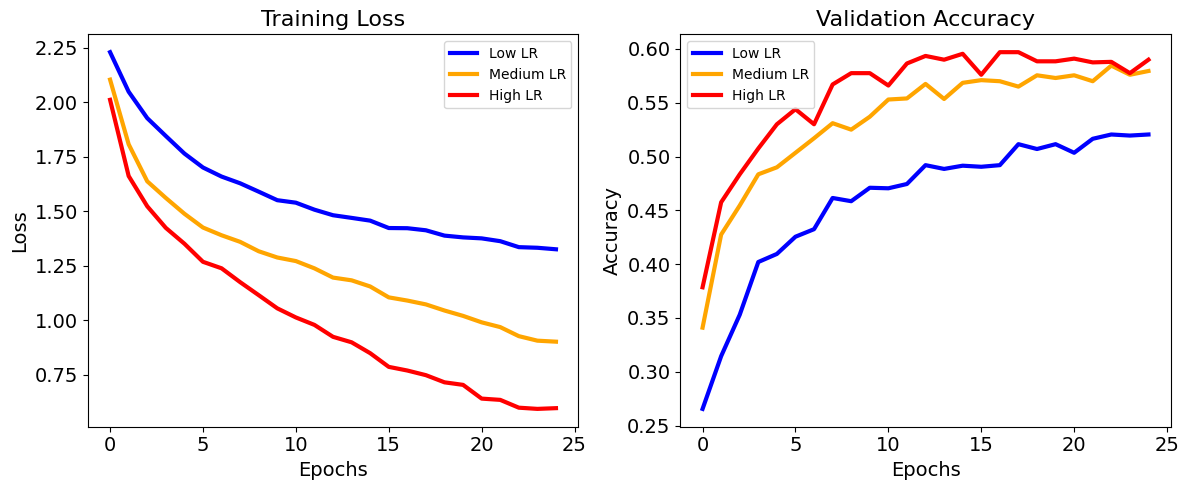

In [7]:
colors = ['blue', 'orange', 'red']
labels = ['Low LR', 'Medium LR', 'High LR']

helper_utils.plot_learning_curves(colors, labels, training_curves)

In [8]:
helper_utils.set_seed(42)
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [9]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.2)

In [15]:
loss_fn = nn.CrossEntropyLoss()
train_loader, val_loader = helper_utils.get_dataset_dataloaders(batch_size = batch_size)

history_LR = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
}

pbar = helper_utils.NestedProgressBar(
    total_epochs = n_epochs,
    total_batches = len(train_loader),
    epoch_message_freq = 5, 
    mode = "train",
)

for epoch in range(n_epochs) :
    pbar.update_epoch(epoch + 1)
    train_loss, train_accuracy = helper_utils.train_epoch(model, train_loader, optimizer, loss_fn, device, pbar)
    val_loss, val_accuracy = helper_utils.evaluate_epoch(model, val_loader, loss_fn, device)
    current_lr = scheduler.get_last_lr()[0]
    
    scheduler.step()
    
    pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Training loss: {train_loss:.4f}, Training accuracy: {train_accuracy:.4f}, LR: {current_lr:.6f}")
    pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Validation loss: {val_loss:.4f}, Validation accuracy: {val_accuracy:.4f}")

    history_LR["train_loss"].append(train_loss)
    history_LR["train_acc"].append(train_accuracy)
    history_LR["val_loss"].append(val_loss)
    history_LR["val_acc"].append(val_accuracy)
    history_LR["lr"].append(current_lr)

pbar.close("Training complete with StepLR scheduler")



Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

At epoch 25: Training loss: 1.2247, Training accuracy: 0.5606, LR: 0.000002
At epoch 25: Validation loss: 1.1024, Validation accuracy: 0.6075
Training complete with StepLR scheduler


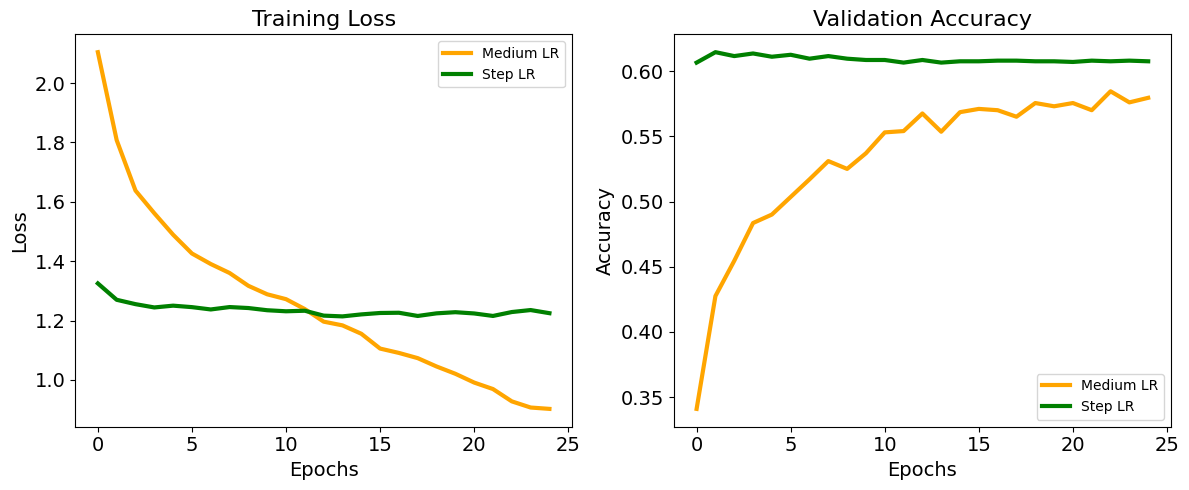

In [16]:
idx = 1
history_constant = training_curves[idx]

colors = ['orange', 'green']
labels = ['Medium LR', 'Step LR']
histories = [history_constant, history_LR]
helper_utils.plot_learning_curves(colors, labels, histories)

In [17]:
def train_and_evaluate_with_scheduler(model, optimizer, scheduler, device, n_epochs=25, batch_size=128):
    helper_utils.set_seed(10)

    loss_fn = nn.CrossEntropyLoss()
    train_loader, val_loader = helper_utils.get_dataset_dataloaders(
        batch_size=batch_size
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        'lr': [],
    }

    pbar = helper_utils.NestedProgressBar(
        total_epochs=n_epochs,
        total_batches=len(train_loader),
        epoch_message_freq=5,
        mode="train",
    )

    for epoch in range(n_epochs):
        pbar.update_epoch(epoch+1)
        train_loss, train_acc = helper_utils.train_epoch(model, train_loader, optimizer, loss_fn, device, pbar)
        val_loss, val_acc = helper_utils.evaluate_epoch(model, val_loader, loss_fn, device)
        current_lr = scheduler.get_last_lr()[0]

        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_acc)
        else:
            scheduler.step()
        
        pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Training loss: {train_loss:.4f}, Training accuracy: {train_acc:.4f}, LR: {current_lr:.6f}")
        pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history['lr'].append(current_lr)

    pbar.close('Training complete!')
    return history

In [ ]:
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)

scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min = 0.0002)

history_cosine = train_and_evaluate_with_scheduler(
    model, optimizer, scheduler_cosine, device, n_epochs=n_epochs, batch_size=batch_size
)

Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

At epoch 15: Training loss: 0.7067, Training accuracy: 0.7316, LR: 0.002150
At epoch 15: Validation loss: 1.3045, Validation accuracy: 0.6040


In [ ]:
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)

scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=3)

history_plateau = train_and_evaluate_with_scheduler(
    model, optimizer, scheduler_plateau, device, n_epochs=n_epochs, batch_size=batch_size
)

In [ ]:
labels = ['Medium LR', 'StepLR', 'CosineAnnealingLR', 'ReducedLRonPlateau']
colors = ['orange', 'green', 'blue', 'purple']

training_curves_new = [history_constant, history_LR, history_cosine, history_plateau]

helper_utils.plot_learning_curves(colors, labels, training_curves_new)